This script plots various aspects of the TrappedResonance objective function

In [21]:
import desc.io
from desc.objectives import (
    TrappedResonance
)
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [22]:
# User Inputs #
eq = desc.io.load("equil_Helios_E0090-13_DESC_fixed.h5")

rhos = (np.linspace(0.1,0.9,30))**(1/2) # rho = sqrt(s)
alphas = np.linspace(0,2*np.pi,1)
KE_frac = np.array([0.01])
pitch_invs = jnp.linspace(4.8,5.3,20)

In [23]:
# Run objective function
obj = TrappedResonance(eq,rho=rhos,pitch_invs=pitch_invs,KE_frac=KE_frac,alpha=alphas,N=0)
obj.build()
obj_out = obj.compute(eq.params_dict) # when not flattened, this shape is (rho,pitch,energy)

Precomputing transforms


In [ ]:
# Plot s vs. obj_out for each pitch inverse
for i in range(0,obj_out.shape[1]): # loop through each pitch angle
    plt.figure(i+1)
    plt.plot(rhos**2,obj_out[:,i,0]) # assuming we are only doing 1 energy for now
    plt.xlabel(r'$s$')
    plt.ylabel('Objective Function Value')
    plt.title('TrappedResonance Objective Function Value for Pitch Inverse = '+str(pitch_invs[i]))
    # plt.ylabel(r'$\omega_{\zeta}$')
    # plt.title(r'$\omega_{\zeta}$ Value for Pitch Inverse = '+str(pitch_invs[i]))
    plt.xlim([0.0,1.0])

Text(0, 0.5, 'Objective Function Value')

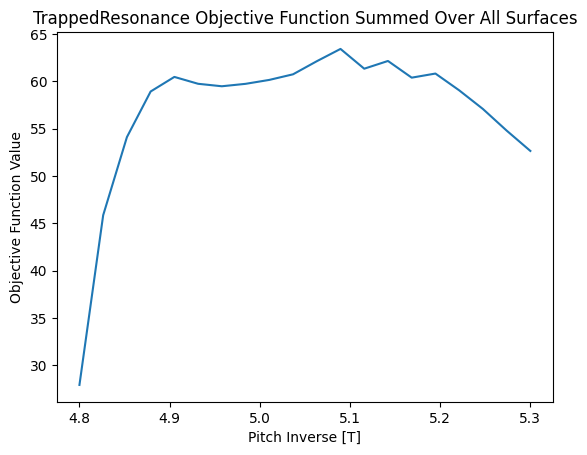

In [25]:
# Plot the value of the TrappedResonance objective (summing over the rho axis) vs. pitch

obj_out_rhosum = np.sum(obj_out,axis=0) # sum over rho axis

plt.figure()
plt.plot(pitch_invs,obj_out_rhosum[:,0])
plt.title("TrappedResonance Objective Function Summed Over All Surfaces")
plt.xlabel("Pitch Inverse [T]")
plt.ylabel("Objective Function Value")